In [10]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

In [11]:
""" Compare unique spike clusters detected by coVar vs SAMRefiner """
SPIKE_REGION = (21563, 25384)

def filter_spike(cluster):
    output = []
    for mut in cluster:
        if int(mut[1:-1]) in range(SPIKE_REGION[0], SPIKE_REGION[1] + 1):
            output.append(mut)
    return output

samrefiner_df = pd.read_csv('../results/samrefiner/jn.1.1_merged.trimmed_unique_seqs.tsv', sep='\t', header=1)
samrefiner_df['clusters'] = samrefiner_df['Unique Sequence'].str.split(' ').str[1:-1].apply(lambda x: [m.split('(')[0] for m in x if ('-' not in m and m != 'Reference') and m.split('(')[0][-1] != 'N']).apply(filter_spike)

samrefiner_df['clusters'] = samrefiner_df['clusters'].apply(lambda x: ' '.join(x))
samrefiner_clusters = set(samrefiner_df['clusters'])
samrefiner_clusters.remove('')

covar_df = pd.read_csv('../results/jn.1.1_coVar.tsv', sep='\t')
covar_df['clusters'] = covar_df['nt_mutations'].str.split(' ').apply(lambda x: [m for m in x if ('-' not in m and '+' not in m)]).apply(filter_spike)
covar_df['clusters'] = covar_df['clusters'].apply(lambda x: ' '.join(x))
covar_clusters = set(covar_df['clusters'])
covar_clusters.remove('')

print(f'SAMRefiner clusters: {len(samrefiner_clusters)}')
print(f'coVar clusters: {len(covar_clusters)}')

SAMRefiner clusters: 9213
coVar clusters: 9213


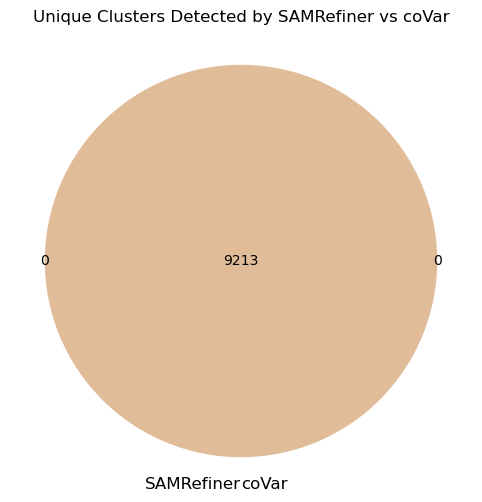

In [ ]:
# Create a Venn diagram

#save clusters in samrefiner that are not in covar
unique_samrefiner_clusters = samrefiner_clusters - covar_clusters
# save to tsv
unique_samrefiner_df = pd.DataFrame(unique_samrefiner_clusters, columns=['clusters'])
unique_samrefiner_df.to_csv('samrefiner_unique_clusters.tsv', sep='\t', index=False)

# save clusters in covar that are not in samrefiner
unique_covar_clusters = covar_clusters - samrefiner_clusters
# save to tsv
unique_covar_df = pd.DataFrame(unique_covar_clusters, columns=['clusters'])
unique_covar_df.to_csv('covar_unique_clusters.tsv', sep='\t', index=False)

plt.figure(figsize=(8, 6))
venn2([samrefiner_clusters, covar_clusters], ('SAMRefiner', 'coVar'))
plt.title('Unique Clusters Detected by SAMRefiner vs coVar')
plt.savefig('../results/samrefiner_vs_covar_venn.pdf', dpi=300, bbox_inches='tight')
plt.show()